# BTP-2: Ship Motion + Propeller Operability Prediction
**Multi-Task Temporal Transformer** | With Propeller Disc Simulation

In [37]:
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, f1_score, classification_report
from scipy import interpolate
import math, warnings, pickle, json, os
warnings.filterwarnings('ignore')
SEED=42; torch.manual_seed(SEED); np.random.seed(SEED)
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f"Device: {device}")

Device: mps


In [38]:
# Verify MPS (Apple GPU) is working
if device.type == 'mps':
    print("Apple MPS GPU active!")
    # MPS fallback for ops not yet supported
    import os
    os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = '1'
    print("MPS fallback enabled for unsupported ops")
elif device.type == 'cuda':
    print(f"CUDA GPU: {torch.cuda.get_device_name(0)}")
else:
    print("Running on CPU")

Apple MPS GPU active!
MPS fallback enabled for unsupported ops


## Configuration

In [39]:
class Config:
    # Data
    INPUT_WINDOW = 100
    OUTPUT_WINDOW = 50
    STRIDE = 10
    SAMPLING_RATE = 10  # Hz

    # Columns in CSV
    WAVE_COL = 'wave[m]'
    MOTION_COLS = ['surge[m]','sway[m]','heave[m]','roll[deg]','pitch[deg]','yaw[deg]']
    ALL_INPUT_FEATURES = ['wave[m]','surge[m]','sway[m]','heave[m]','roll[deg]','pitch[deg]','yaw[deg]']
    NUM_INPUT_FEATURES = 7
    NUM_MOTION_FEATURES = 6
    HEAVE_IDX_IN_INPUT = 3  # index of heave in ALL_INPUT_FEATURES

    # Propeller params (tunable)
    H_PROP_STATIC = 0.2  # static depth of propeller top below waterline (meters)

    # Model
    D_MODEL = 128; NHEAD = 8; NUM_ENCODER_LAYERS = 4; DIM_FEEDFORWARD = 512
    DROPOUT = 0.1; ACTIVATION = 'gelu'

    # Loss weights
    W_MOTION = 1.0; W_ESCORE = 0.5; W_EFLAG = 0.3

    # Training
    BATCH_SIZE = 32; EPOCHS = 100; LEARNING_RATE = 1e-3
    WEIGHT_DECAY = 1e-5; EARLY_STOPPING_PATIENCE = 15
    LR_PATIENCE = 5; LR_FACTOR = 0.5; GRAD_CLIP = 1.0

    TEST_SIZE = 0.2; VAL_SIZE = 0.2
    SAVE_DIR = './BTP2_outputs'

config = Config()
os.makedirs(config.SAVE_DIR, exist_ok=True)
print("Config loaded. Input features:", config.ALL_INPUT_FEATURES)

Config loaded. Input features: ['wave[m]', 'surge[m]', 'sway[m]', 'heave[m]', 'roll[deg]', 'pitch[deg]', 'yaw[deg]']


## Data Loading & EDA

In [40]:
# --- EDIT THIS PATH ---
DATA_PATH = 'BTP_2_data - Sheet1.csv'

df_raw = pd.read_csv(DATA_PATH)
print(df_raw.shape, df_raw.columns.tolist())
print(df_raw.head())
print("\nStatistics:")
print(df_raw.describe())

(6733, 8) ['time[s]', 'wave[m]', 'surge[m]', 'sway[m]', 'heave[m]', 'roll[deg]', 'pitch[deg]', 'yaw[deg]']
   time[s]   wave[m]  surge[m]   sway[m]  heave[m]  roll[deg]  pitch[deg]  \
0    0.000  0.000000 -1.336488 -1.310962 -0.316702  -0.119952    2.449760   
1    1.000  1.444140 -1.151366 -1.301193  0.692166  -0.010124    2.180684   
2    2.048  2.764178 -0.806025 -1.119499  1.656073   0.106073    1.611891   
3    2.127  2.850518 -0.774888 -1.099229  1.721146   0.114441    1.559018   
4    2.207  2.935698 -0.742744 -1.077834  1.785681   0.122824    1.504243   

   yaw[deg]  
0  0.208170  
1 -0.159486  
2 -0.522981  
3 -0.548088  
4 -0.573079  

Statistics:
           time[s]      wave[m]     surge[m]      sway[m]     heave[m]  \
count  6733.000000  6733.000000  6733.000000  6733.000000  6733.000000   
mean    271.537274     0.014435    -0.002540    -0.004209     0.009044   
std     155.114088     2.962002     0.966103     0.937758     2.040516   
min       0.000000    -4.182711    -1

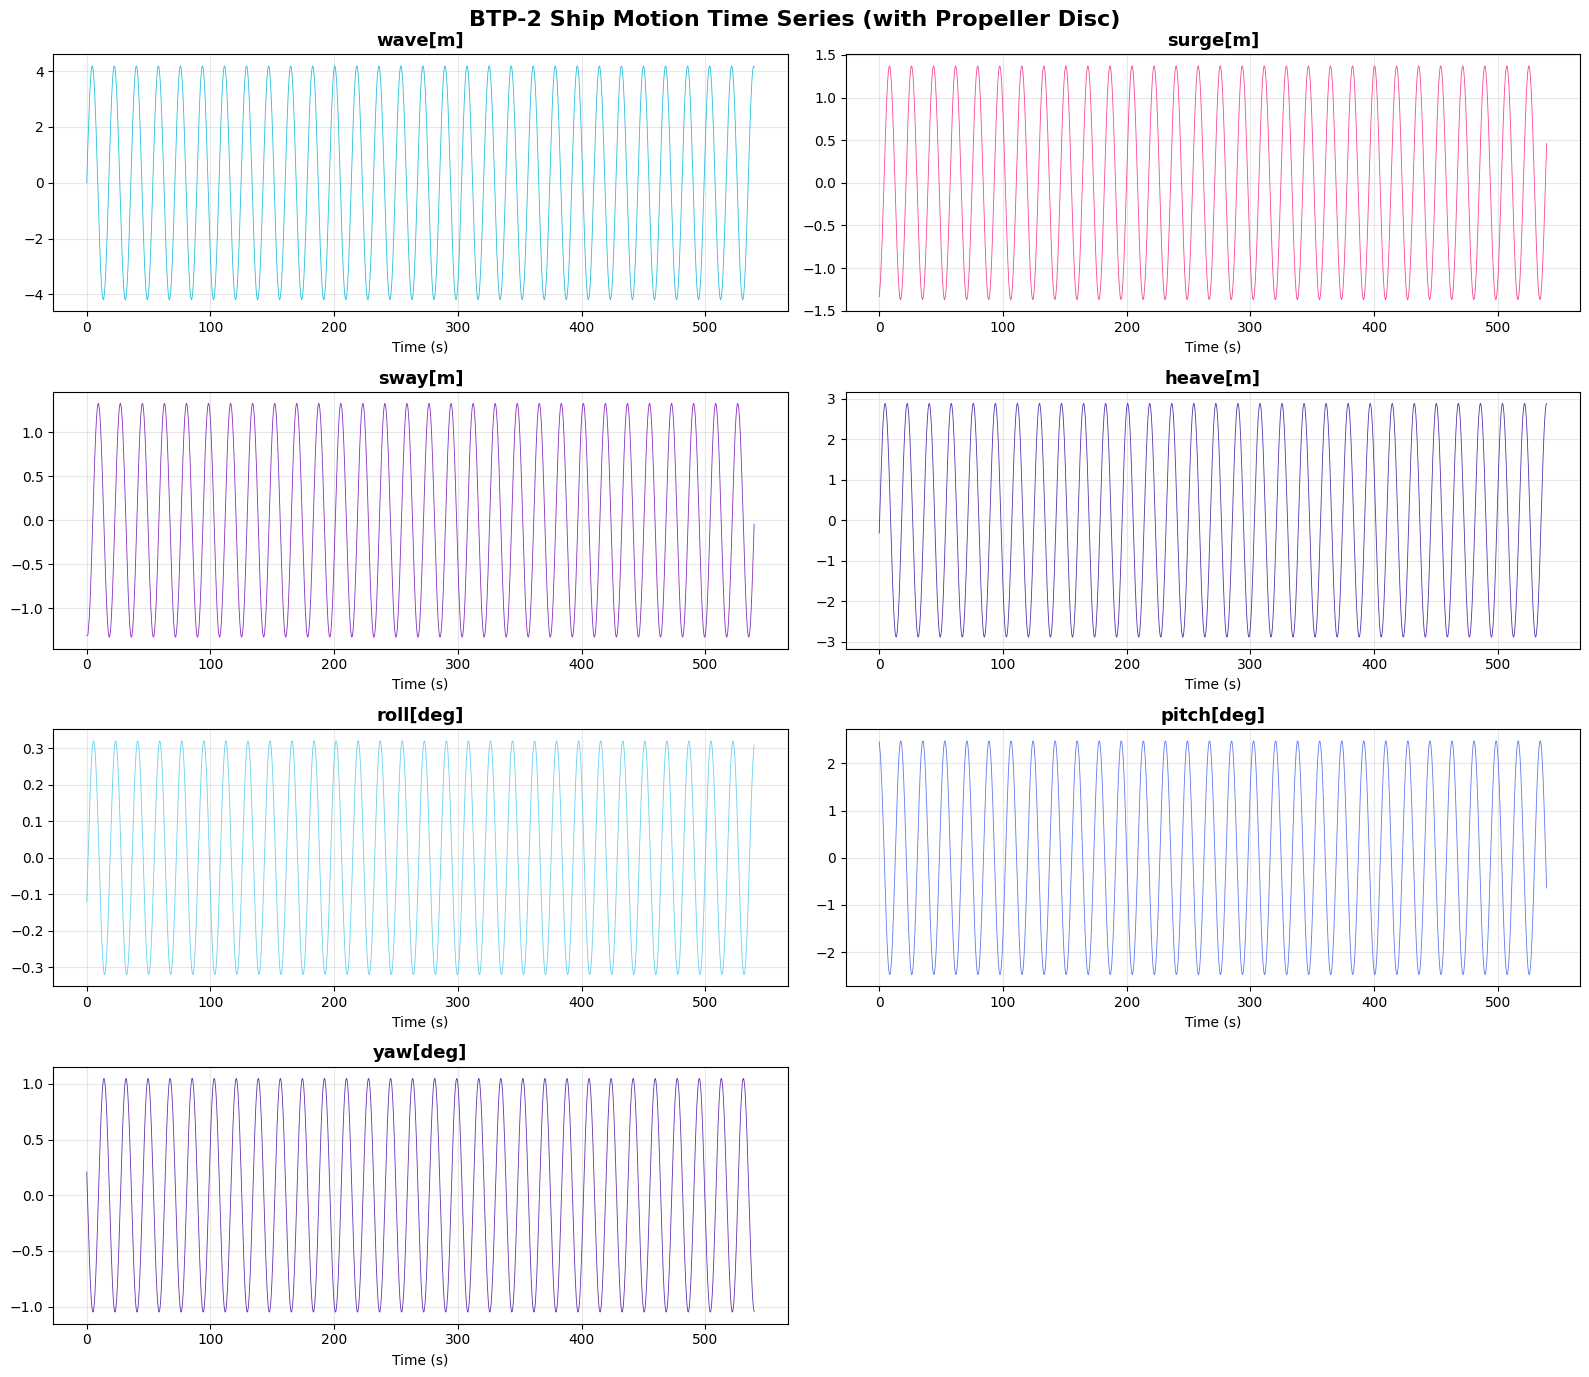

In [41]:
fig, axes = plt.subplots(4,2, figsize=(16,14))
axes = axes.flatten()
cols = ['wave[m]','surge[m]','sway[m]','heave[m]','roll[deg]','pitch[deg]','yaw[deg]']
colors = ['#00b4d8','#f72585','#7209b7','#3a0ca3','#4cc9f0','#4361ee','#480ca8']
for i,(col,c) in enumerate(zip(cols,colors)):
    axes[i].plot(df_raw['time[s]'], df_raw[col], color=c, linewidth=0.6, alpha=0.85)
    axes[i].set_title(col, fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Time (s)'); axes[i].grid(alpha=0.3)
axes[-1].set_visible(False)
plt.suptitle('BTP-2 Ship Motion Time Series (with Propeller Disc)', fontsize=16, fontweight='bold')
plt.tight_layout(); plt.savefig(f'{config.SAVE_DIR}/raw_signals.png', dpi=150); plt.show()

## Preprocessing + Propeller Emergence Engineering

In [42]:
class DataPreprocessor:
    def __init__(self, config):
        self.config = config
        self.scaler = StandardScaler()

    def load_data(self, path):
        print("Loading data...")
        df = pd.read_csv(path)
        df.columns = [c.strip() for c in df.columns]
        df = df.rename(columns={'time[s]':'time'})
        df = df.dropna()
        df = df.sort_values('time').reset_index(drop=True)
        # Remove duplicate times
        df = df.drop_duplicates(subset='time').reset_index(drop=True)
        print(f"  Loaded {len(df)} rows, time: {df['time'].min():.2f}s -> {df['time'].max():.2f}s")
        self.raw_df = df
        return df

    def interpolate_uniform(self, df):
        print("Interpolating to 10 Hz...")
        t0, t1 = df['time'].min(), df['time'].max()
        t_uni = np.arange(t0, t1, 1/self.config.SAMPLING_RATE)
        out = {'time': t_uni}
        for col in self.config.ALL_INPUT_FEATURES:
            fn = interpolate.interp1d(df['time'], df[col], kind='cubic', fill_value='extrapolate')
            out[col] = fn(t_uni)
        df_uni = pd.DataFrame(out)
        print(f"  Interpolated to {len(df_uni)} timesteps")
        return df_uni

    def compute_propeller_features(self, df):
        print("Computing propeller emergence features...")
        # Use heave as vertical motion proxy at propeller center
        heave = df['heave[m]'].values
        # Rolling window upward amplitude (half window = 0.5s = 5 steps)
        win = 5
        heave_series = pd.Series(heave)
        rolling_max = heave_series.rolling(win, center=True, min_periods=1).max()
        rolling_min = heave_series.rolling(win, center=True, min_periods=1).min()
        amplitude = (rolling_max - rolling_min) / 2.0
        E_score = amplitude / self.config.H_PROP_STATIC
        E_flag = (E_score >= 1.0).astype(float)
        df = df.copy()
        df['emergence_score'] = E_score.values
        df['emergence_flag'] = E_flag.values
        pct = E_flag.mean()*100
        print(f"  Emergence flag=1: {pct:.1f}% of timesteps")
        return df

    def normalize(self, data, fit=True):
        if fit:
            return self.scaler.fit_transform(data)
        return self.scaler.transform(data)

    def create_sequences(self, df_full):
        print("Creating sequences...")
        cfg = self.config
        feat_data = df_full[cfg.ALL_INPUT_FEATURES].values
        escore = df_full['emergence_score'].values
        eflag = df_full['emergence_flag'].values

        # Normalize feature data
        feat_norm = self.normalize(feat_data, fit=True)

        # Normalize emergence score separately
        self.escore_mean = escore.mean()
        self.escore_std = escore.std() + 1e-8
        escore_norm = (escore - self.escore_mean) / self.escore_std

        X, y_motion, y_escore, y_eflag = [], [], [], []
        motion_idxs = [cfg.ALL_INPUT_FEATURES.index(c) for c in cfg.MOTION_COLS]
        total = len(feat_norm) - cfg.INPUT_WINDOW - cfg.OUTPUT_WINDOW + 1

        for i in range(0, total, cfg.STRIDE):
            X.append(feat_norm[i:i+cfg.INPUT_WINDOW])
            out_s, out_e = i+cfg.INPUT_WINDOW, i+cfg.INPUT_WINDOW+cfg.OUTPUT_WINDOW
            y_motion.append(feat_norm[out_s:out_e][:, motion_idxs])
            y_escore.append(escore_norm[out_s:out_e])
            y_eflag.append(eflag[out_s:out_e])

        X = np.array(X, dtype=np.float32)
        y_motion = np.array(y_motion, dtype=np.float32)
        y_escore = np.array(y_escore, dtype=np.float32)[..., np.newaxis]
        y_eflag = np.array(y_eflag, dtype=np.float32)[..., np.newaxis]
        print(f"  Sequences: X={X.shape}, y_motion={y_motion.shape}, y_escore={y_escore.shape}, y_eflag={y_eflag.shape}")
        return X, y_motion, y_escore, y_eflag

    def split(self, *arrays):
        n = len(arrays[0])
        test_cut = int(n*(1-self.config.TEST_SIZE))
        val_cut = int(test_cut*(1-self.config.VAL_SIZE))
        result = []
        for arr in arrays:
            result.append((arr[:val_cut], arr[val_cut:test_cut], arr[test_cut:]))
        return result

    def run(self, path):
        df = self.load_data(path)
        df_uni = self.interpolate_uniform(df)
        df_feat = self.compute_propeller_features(df_uni)
        X, ym, ye, yf = self.create_sequences(df_feat)
        splits = self.split(X, ym, ye, yf)
        (Xtr,Xva,Xte),(ymtr,ymva,ymte),(yetr,yeva,yete),(yftr,yfva,yfte) = splits
        print(f"  Train/Val/Test: {len(Xtr)}/{len(Xva)}/{len(Xte)}")
        return Xtr,Xva,Xte, ymtr,ymva,ymte, yetr,yeva,yete, yftr,yfva,yfte

## Dataset & DataLoaders

In [43]:
class ShipMotionDataset(Dataset):
    def __init__(self, X, y_motion, y_escore, y_eflag):
        self.X = torch.from_numpy(X)
        self.y_motion = torch.from_numpy(y_motion)
        self.y_escore = torch.from_numpy(y_escore)
        self.y_eflag = torch.from_numpy(y_eflag)
    def __len__(self): return len(self.X)
    def __getitem__(self, i):
        return self.X[i], self.y_motion[i], self.y_escore[i], self.y_eflag[i]

## Positional Encoding

In [44]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0)/d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])

## Multi-Task Transformer Architecture

In [45]:
class MultiTaskShipTransformer(nn.Module):
    """
    Shared Transformer encoder with three heads:
    1. Motion regression  -> [B, OUTPUT_WINDOW, 6]
    2. Emergence score    -> [B, OUTPUT_WINDOW, 1]
    3. Emergence flag     -> [B, OUTPUT_WINDOW, 1] (sigmoid)
    """
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        # Input projection
        self.input_proj = nn.Sequential(
            nn.Linear(cfg.NUM_INPUT_FEATURES, cfg.D_MODEL),
            nn.LayerNorm(cfg.D_MODEL)
        )
        self.pos_enc = PositionalEncoding(cfg.D_MODEL, dropout=cfg.DROPOUT)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=cfg.D_MODEL, nhead=cfg.NHEAD,
            dim_feedforward=cfg.DIM_FEEDFORWARD,
            dropout=cfg.DROPOUT, activation=cfg.ACTIVATION,
            batch_first=True, norm_first=True
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=cfg.NUM_ENCODER_LAYERS, enable_nested_tensor=False)

        # Shared feature extractor after pooling
        self.shared_head = nn.Sequential(
            nn.Linear(cfg.D_MODEL, 256), nn.GELU(), nn.Dropout(cfg.DROPOUT),
            nn.Linear(256, cfg.OUTPUT_WINDOW * 128), nn.GELU()
        )

        # Task-specific output heads
        out_d = 128
        self.motion_head = nn.Sequential(
            nn.Linear(out_d, 64), nn.GELU(),
            nn.Linear(64, cfg.NUM_MOTION_FEATURES)
        )
        self.escore_head = nn.Sequential(
            nn.Linear(out_d, 32), nn.GELU(),
            nn.Linear(32, 1)
        )
        self.eflag_head = nn.Sequential(
            nn.Linear(out_d, 32), nn.GELU(),
            nn.Linear(32, 1)
        )
        self._init_weights()

    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1: nn.init.xavier_uniform_(p)

    def forward(self, x):
        B = x.size(0)
        x = self.input_proj(x)
        x = self.pos_enc(x)
        x = self.encoder(x)
        x = x.mean(dim=1)  # temporal pooling -> [B, D_MODEL]
        shared = self.shared_head(x)  # [B, OUTPUT_WINDOW*128]
        shared = shared.view(B, self.cfg.OUTPUT_WINDOW, 128)  # [B, T_out, 128]

        motion = self.motion_head(shared)       # [B, T_out, 6]
        escore = self.escore_head(shared)       # [B, T_out, 1]
        eflag = torch.sigmoid(self.eflag_head(shared))  # [B, T_out, 1]
        return motion, escore, eflag

# Quick shape test
_m = MultiTaskShipTransformer(config).to(device)
_x = torch.randn(2, config.INPUT_WINDOW, config.NUM_INPUT_FEATURES).to(device)
_mo, _es, _ef = _m(_x)
print(f"Output shapes -> motion:{_mo.shape}  escore:{_es.shape}  eflag:{_ef.shape}")
del _m, _x, _mo, _es, _ef

Output shapes -> motion:torch.Size([2, 50, 6])  escore:torch.Size([2, 50, 1])  eflag:torch.Size([2, 50, 1])


## Trainer (Multi-Task Loss + Early Stopping)

In [46]:
class MultiTaskLoss(nn.Module):
    def __init__(self, w_motion=1.0, w_escore=0.5, w_eflag=0.3):
        super().__init__()
        self.w_motion = w_motion; self.w_escore = w_escore; self.w_eflag = w_eflag
        self.mse = nn.MSELoss(); self.bce = nn.BCELoss()
    def forward(self, pred_m, pred_es, pred_ef, true_m, true_es, true_ef):
        l_m = self.mse(pred_m, true_m)
        l_es = self.mse(pred_es, true_es)
        l_ef = self.bce(pred_ef, true_ef)
        total = self.w_motion*l_m + self.w_escore*l_es + self.w_eflag*l_ef
        return total, l_m, l_es, l_ef


class Trainer:
    def __init__(self, model, config, device):
        self.model = model.to(device)
        self.cfg = config; self.device = device
        self.criterion = MultiTaskLoss(config.W_MOTION, config.W_ESCORE, config.W_EFLAG)
        self.optimizer = optim.AdamW(model.parameters(), lr=config.LEARNING_RATE, weight_decay=config.WEIGHT_DECAY)
        self.scheduler = optim.lr_scheduler.ReduceLROnPlateau(self.optimizer, patience=config.LR_PATIENCE, factor=config.LR_FACTOR)
        self.best_val = float('inf'); self.patience_ctr = 0
        self.history = {k:[] for k in ['train_loss','val_loss','l_motion','l_escore','l_eflag']}

    def _step(self, loader, train=True):
        self.model.train(train)
        tot, lm_t, les_t, lef_t, n = 0,0,0,0,0
        ctx = torch.enable_grad() if train else torch.no_grad()
        with ctx:
            for X, ym, yes, yef in loader:
                X,ym,yes,yef = X.to(self.device),ym.to(self.device),yes.to(self.device),yef.to(self.device)
                pm, pes, pef = self.model(X)
                loss,lm,les,lef = self.criterion(pm,pes,pef,ym,yes,yef)
                if train:
                    self.optimizer.zero_grad(); loss.backward()
                    nn.utils.clip_grad_norm_(self.model.parameters(), self.cfg.GRAD_CLIP)
                    self.optimizer.step()
                b = X.size(0); tot+=loss.item()*b; lm_t+=lm.item()*b; les_t+=les.item()*b; lef_t+=lef.item()*b; n+=b
        return tot/n, lm_t/n, les_t/n, lef_t/n

    def train(self, tr_loader, va_loader):
        print("="*60)
        print("TRAINING MULTI-TASK SHIP MOTION TRANSFORMER")
        print("="*60)
        for epoch in range(1, self.cfg.EPOCHS+1):
            tl,_,_,_ = self._step(tr_loader, train=True)
            vl,lm,les,lef = self._step(va_loader, train=False)
            self.scheduler.step(vl)
            self.history['train_loss'].append(tl); self.history['val_loss'].append(vl)
            self.history['l_motion'].append(lm); self.history['l_escore'].append(les); self.history['l_eflag'].append(lef)
            if epoch%5==0 or epoch==1:
                print(f"Epoch {epoch:3d} | Train:{tl:.5f} | Val:{vl:.5f} | Motion:{lm:.5f} | EScore:{les:.5f} | EFlag:{lef:.5f}")
            if vl < self.best_val:
                self.best_val = vl; self.patience_ctr = 0
                torch.save(self.model.state_dict(), f'{self.cfg.SAVE_DIR}/best_model.pth')
            else:
                self.patience_ctr += 1
                if self.patience_ctr >= self.cfg.EARLY_STOPPING_PATIENCE:
                    print(f"Early stop at epoch {epoch}"); break
        print(f"Best val loss: {self.best_val:.6f}")
        return self.history

    def load_best(self): self.model.load_state_dict(torch.load(f'{self.cfg.SAVE_DIR}/best_model.pth', map_location='cpu'))

    def evaluate(self, loader):
        self.model.eval()
        all_pm, all_pes, all_pef = [], [], []
        all_tm, all_tes, all_tef = [], [], []
        with torch.no_grad():
            for X,ym,yes,yef in loader:
                X = X.to(self.device)
                pm,pes,pef = self.model(X)
                all_pm.append(pm.cpu().numpy()); all_pes.append(pes.cpu().numpy()); all_pef.append(pef.cpu().numpy())
                all_tm.append(ym.numpy()); all_tes.append(yes.numpy()); all_tef.append(yef.numpy())
        return (np.concatenate(all_pm), np.concatenate(all_pes), np.concatenate(all_pef),
                np.concatenate(all_tm), np.concatenate(all_tes), np.concatenate(all_tef))

## Run Preprocessing & Create DataLoaders

In [47]:
preprocessor = DataPreprocessor(config)
Xtr,Xva,Xte,ymtr,ymva,ymte,yetr,yeva,yete,yftr,yfva,yfte = preprocessor.run(DATA_PATH)

def make_loader(X,ym,ye,yf,shuffle=False):
    ds = ShipMotionDataset(X,ym,ye,yf)
    return DataLoader(ds, batch_size=config.BATCH_SIZE, shuffle=shuffle, num_workers=0, pin_memory=False)

train_loader = make_loader(Xtr,ymtr,yetr,yftr,shuffle=True)
val_loader   = make_loader(Xva,ymva,yeva,yfva)
test_loader  = make_loader(Xte,ymte,yete,yfte)
print(f"Loaders: train={len(train_loader)} val={len(val_loader)} test={len(test_loader)} batches")

Loading data...
  Loaded 6733 rows, time: 0.00s -> 539.51s
Interpolating to 10 Hz...
  Interpolated to 5396 timesteps
Computing propeller emergence features...
  Emergence flag=1: 11.1% of timesteps
Creating sequences...
  Sequences: X=(525, 100, 7), y_motion=(525, 50, 6), y_escore=(525, 50, 1), y_eflag=(525, 50, 1)
  Train/Val/Test: 336/84/105
Loaders: train=11 val=3 test=4 batches


## Initialize Model & Train

In [48]:
model = MultiTaskShipTransformer(config)
total_params = sum(p.numel() for p in model.parameters())
print(f"Parameters: {total_params:,}")
trainer = Trainer(model, config, device)
history = trainer.train(train_loader, val_loader)

Parameters: 2,489,160
TRAINING MULTI-TASK SHIP MOTION TRANSFORMER
Epoch   1 | Train:0.78112 | Val:0.21882 | Motion:0.06194 | EScore:0.12605 | EFlag:0.31286
Epoch   5 | Train:0.07819 | Val:0.05403 | Motion:0.00493 | EScore:0.02104 | EFlag:0.12861
Epoch  10 | Train:0.07016 | Val:0.05708 | Motion:0.00780 | EScore:0.04753 | EFlag:0.08507
Epoch  15 | Train:0.04124 | Val:0.02478 | Motion:0.00291 | EScore:0.00848 | EFlag:0.05876
Epoch  20 | Train:0.02364 | Val:0.01908 | Motion:0.00254 | EScore:0.00632 | EFlag:0.04460
Epoch  25 | Train:0.02539 | Val:0.02348 | Motion:0.00386 | EScore:0.01040 | EFlag:0.04805
Epoch  30 | Train:0.02146 | Val:0.01364 | Motion:0.00155 | EScore:0.00456 | EFlag:0.03273
Epoch  35 | Train:0.01595 | Val:0.01157 | Motion:0.00119 | EScore:0.00355 | EFlag:0.02870
Epoch  40 | Train:0.01572 | Val:0.00985 | Motion:0.00091 | EScore:0.00306 | EFlag:0.02471
Epoch  45 | Train:0.01337 | Val:0.00940 | Motion:0.00099 | EScore:0.00273 | EFlag:0.02347
Epoch  50 | Train:0.01421 | Val:0.

## Training Curves

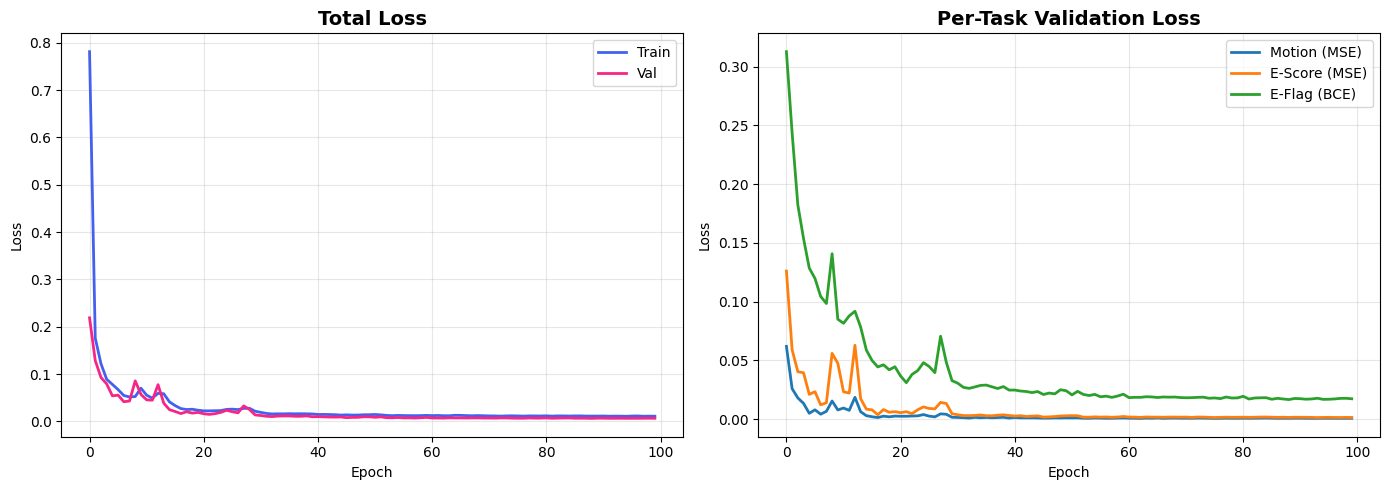

In [49]:
fig, axes = plt.subplots(1,2, figsize=(14,5))
axes[0].plot(history['train_loss'], label='Train', linewidth=2, color='#4361ee')
axes[0].plot(history['val_loss'], label='Val', linewidth=2, color='#f72585')
axes[0].set_title('Total Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history['l_motion'], label='Motion (MSE)', linewidth=2)
axes[1].plot(history['l_escore'], label='E-Score (MSE)', linewidth=2)
axes[1].plot(history['l_eflag'], label='E-Flag (BCE)', linewidth=2)
axes[1].set_title('Per-Task Validation Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.savefig(f'{config.SAVE_DIR}/training_curves.png', dpi=150); plt.show()

## Evaluate on Test Set

In [50]:
trainer.load_best()
pred_m, pred_es, pred_ef, true_m, true_es, true_ef = trainer.evaluate(test_loader)

# Denormalize motion predictions
motion_idxs = [config.ALL_INPUT_FEATURES.index(c) for c in config.MOTION_COLS]
mot_means = preprocessor.scaler.mean_[motion_idxs]
mot_scales = preprocessor.scaler.scale_[motion_idxs]

pred_m_real = pred_m * mot_scales + mot_means
true_m_real = true_m * mot_scales + mot_means

# Denormalize emergence score
pred_es_real = pred_es.squeeze(-1) * preprocessor.escore_std + preprocessor.escore_mean
true_es_real = true_es.squeeze(-1) * preprocessor.escore_std + preprocessor.escore_mean

# Motion metrics
mse = np.mean((pred_m_real - true_m_real)**2)
rmse = np.sqrt(mse)
mae  = np.mean(np.abs(pred_m_real - true_m_real))
ss_res = np.sum((true_m_real - pred_m_real)**2)
ss_tot = np.sum((true_m_real - true_m_real.mean())**2)
r2 = 1 - ss_res/ss_tot

print("="*60)
print("MOTION REGRESSION METRICS")
print(f"  MSE:  {mse:.6f}")
print(f"  RMSE: {rmse:.6f}")
print(f"  MAE:  {mae:.6f}")
print(f"  R²:   {r2:.4f}")

print("\nPER DOF RMSE:")
for i,col in enumerate(config.MOTION_COLS):
    r = np.sqrt(np.mean((pred_m_real[:,:,i]-true_m_real[:,:,i])**2))
    print(f"  {col:20s}: {r:.6f}")

# Emergence flag metrics (flatten over all timesteps and samples)
ef_pred_flat = pred_ef.squeeze(-1).flatten()
ef_true_flat = true_ef.squeeze(-1).flatten()
ef_binary = (ef_pred_flat >= 0.5).astype(int)
ef_true_int = ef_true_flat.astype(int)

print("\nEMERGENCE FLAG METRICS:")
try:
    auc = roc_auc_score(ef_true_int, ef_pred_flat)
    print(f"  AUC-ROC: {auc:.4f}")
except: print("  AUC: N/A (single class)")
f1 = f1_score(ef_true_int, ef_binary, zero_division=0)
print(f"  F1 Score: {f1:.4f}")
print(classification_report(ef_true_int, ef_binary, labels=[0, 1], target_names=['No Emergence','Emergence'], zero_division=0))

# Emergence score metrics
es_rmse = np.sqrt(np.mean((pred_es_real - true_es_real)**2))
print(f"EMERGENCE SCORE RMSE: {es_rmse:.6f}")

MOTION REGRESSION METRICS
  MSE:  0.001092
  RMSE: 0.033038
  MAE:  0.023694
  R²:   0.9993

PER DOF RMSE:
  surge[m]            : 0.022000
  sway[m]             : 0.021867
  heave[m]            : 0.056256
  roll[deg]           : 0.006492
  pitch[deg]          : 0.043887
  yaw[deg]            : 0.021305

EMERGENCE FLAG METRICS:
  AUC-ROC: 0.9999
  F1 Score: 0.9906
              precision    recall  f1-score   support

No Emergence       1.00      1.00      1.00      4666
   Emergence       0.99      0.99      0.99       584

    accuracy                           1.00      5250
   macro avg       0.99      1.00      0.99      5250
weighted avg       1.00      1.00      1.00      5250

EMERGENCE SCORE RMSE: 0.011629


## Visualizations

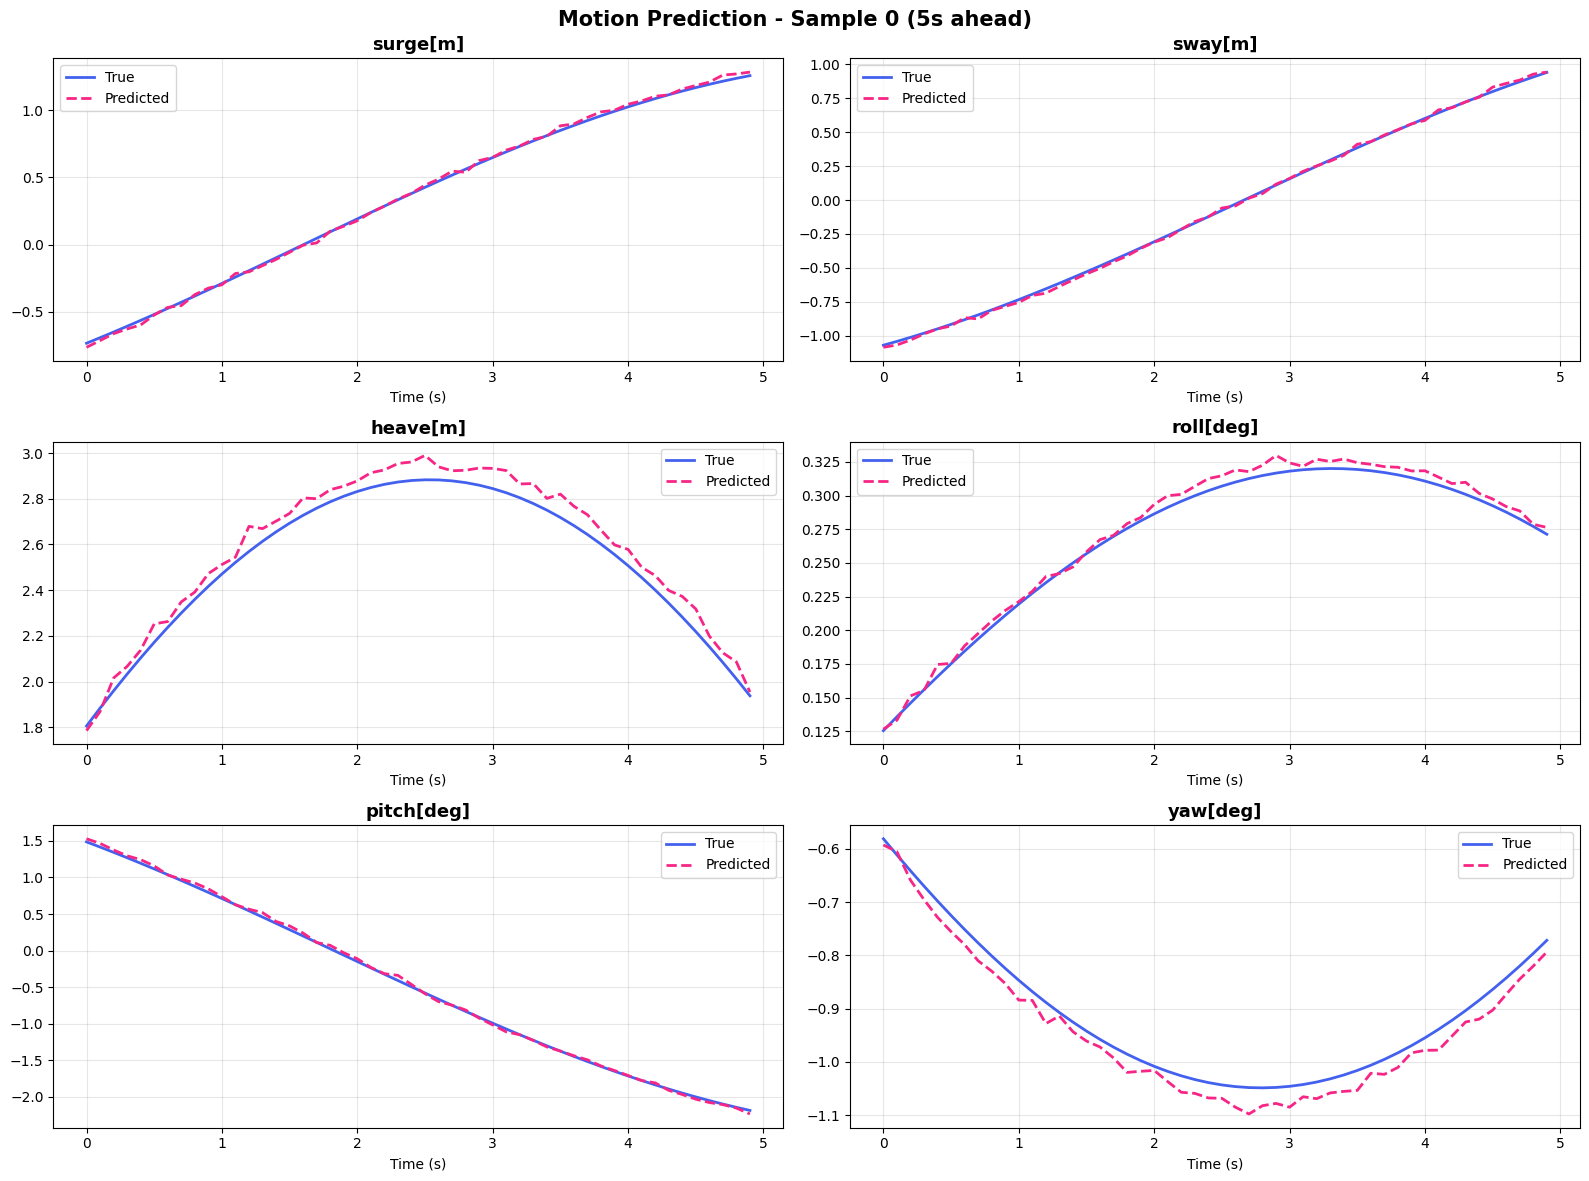

In [51]:
# Plot motion predictions for one sample
SAMPLE = 0
fig, axes = plt.subplots(3,2, figsize=(16,12))
axes = axes.flatten()
t_out = np.arange(config.OUTPUT_WINDOW) / config.SAMPLING_RATE
for i,(col,ax) in enumerate(zip(config.MOTION_COLS, axes)):
    ax.plot(t_out, true_m_real[SAMPLE,:,i], label='True', linewidth=2, color='#4361ee')
    ax.plot(t_out, pred_m_real[SAMPLE,:,i], label='Predicted', linewidth=2, color='#f72585', linestyle='--')
    ax.set_title(col, fontsize=13, fontweight='bold')
    ax.set_xlabel('Time (s)'); ax.legend(); ax.grid(alpha=0.3)
plt.suptitle('Motion Prediction - Sample 0 (5s ahead)', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.savefig(f'{config.SAVE_DIR}/motion_predictions.png', dpi=150); plt.show()

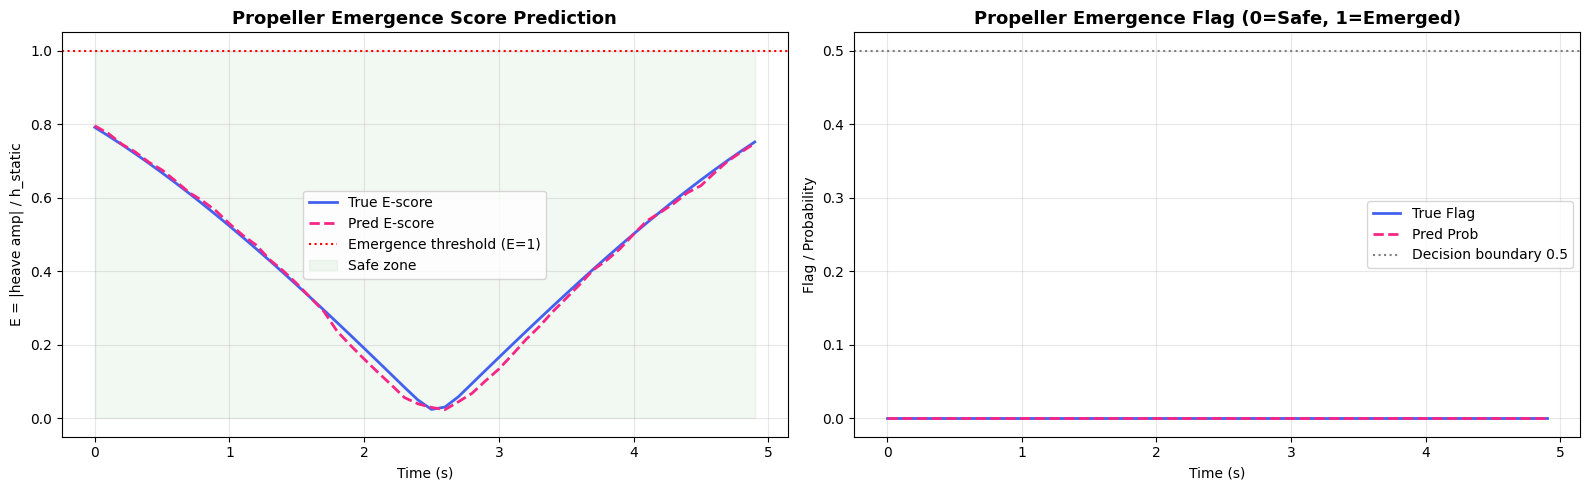

In [52]:
# Emergence score prediction plot
fig, axes = plt.subplots(1,2, figsize=(16,5))
t_out = np.arange(config.OUTPUT_WINDOW) / config.SAMPLING_RATE

ax = axes[0]
ax.plot(t_out, true_es_real[SAMPLE], label='True E-score', linewidth=2, color='#4361ee')
ax.plot(t_out, pred_es_real[SAMPLE], label='Pred E-score', linewidth=2, color='#f72585', linestyle='--')
ax.axhline(y=1.0, color='red', linestyle=':', linewidth=1.5, label='Emergence threshold (E=1)')
ax.fill_between(t_out, 0, 1, alpha=0.05, color='green', label='Safe zone')
ax.set_title('Propeller Emergence Score Prediction', fontsize=13, fontweight='bold')
ax.set_xlabel('Time (s)'); ax.set_ylabel('E = |heave amp| / h_static'); ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
p_ef = pred_ef[SAMPLE,:,0]; t_ef = true_ef[SAMPLE,:,0]
ax.step(t_out, t_ef, label='True Flag', linewidth=2, color='#4361ee', where='post')
ax.step(t_out, p_ef, label='Pred Prob', linewidth=2, color='#f72585', linestyle='--', where='post')
ax.axhline(y=0.5, color='gray', linestyle=':', linewidth=1.5, label='Decision boundary 0.5')
ax.set_title('Propeller Emergence Flag (0=Safe, 1=Emerged)', fontsize=13, fontweight='bold')
ax.set_xlabel('Time (s)'); ax.set_ylabel('Flag / Probability'); ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout(); plt.savefig(f'{config.SAVE_DIR}/emergence_predictions.png', dpi=150); plt.show()

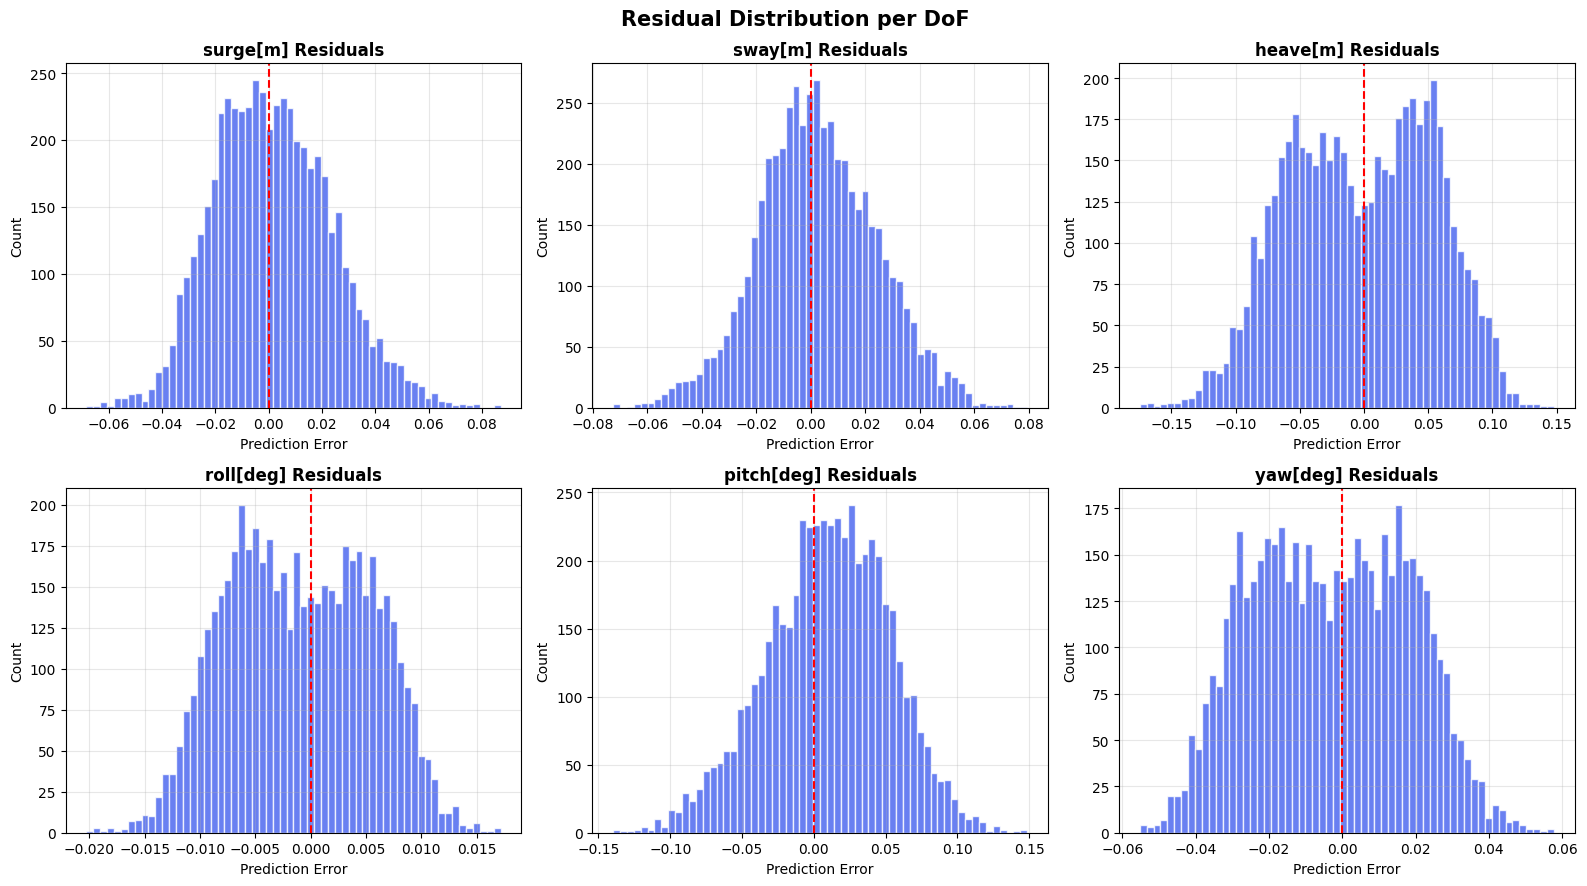

In [53]:
# Residual analysis (motion)
fig, axes = plt.subplots(2,3, figsize=(16,9))
axes = axes.flatten()
for i,(col,ax) in enumerate(zip(config.MOTION_COLS, axes)):
    res = (pred_m_real[:,:,i] - true_m_real[:,:,i]).flatten()
    ax.hist(res, bins=60, color='#4361ee', alpha=0.8, edgecolor='white')
    ax.axvline(0, color='red', linewidth=1.5, linestyle='--')
    ax.set_title(f'{col} Residuals', fontsize=12, fontweight='bold')
    ax.set_xlabel('Prediction Error'); ax.set_ylabel('Count'); ax.grid(alpha=0.3)
plt.suptitle('Residual Distribution per DoF', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.savefig(f'{config.SAVE_DIR}/residuals.png', dpi=150); plt.show()

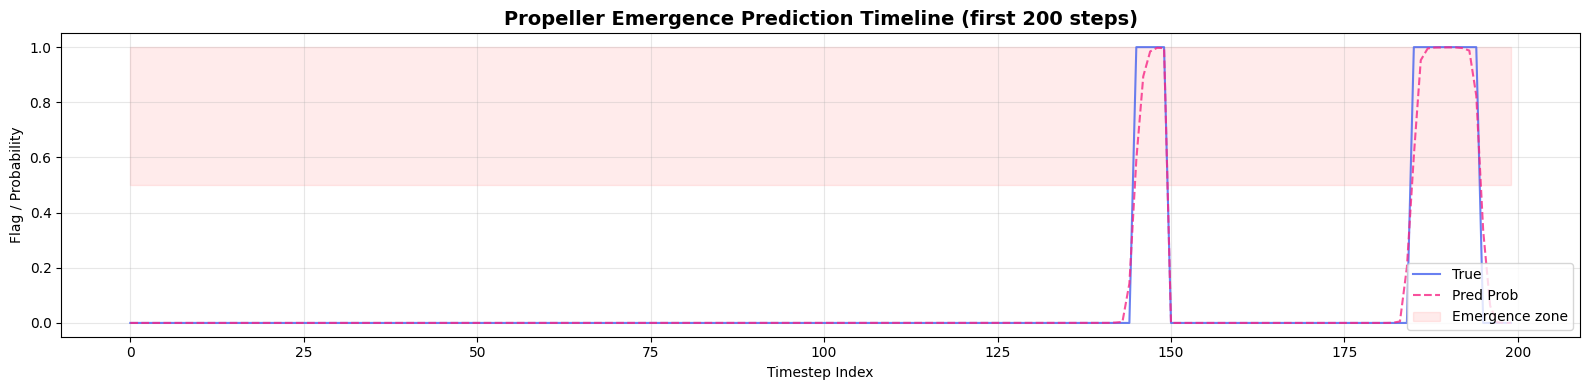

In [54]:
# Overall emergence timeline on a batch
fig, ax = plt.subplots(figsize=(16,4))
n_show = min(200, len(ef_true_flat))
t_show = np.arange(n_show)
ax.plot(t_show, ef_true_flat[:n_show], label='True', linewidth=1.5, color='#4361ee', alpha=0.8)
ax.plot(t_show, ef_pred_flat[:n_show], label='Pred Prob', linewidth=1.5, color='#f72585', linestyle='--', alpha=0.8)
ax.fill_between(t_show, 0.5, 1, alpha=0.08, color='red', label='Emergence zone')
ax.set_title('Propeller Emergence Prediction Timeline (first 200 steps)', fontsize=14, fontweight='bold')
ax.set_xlabel('Timestep Index'); ax.set_ylabel('Flag / Probability'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(f'{config.SAVE_DIR}/emergence_timeline.png', dpi=150); plt.show()

## Save Artifacts

In [55]:
# Save model weights
torch.save(model.state_dict(), f'{config.SAVE_DIR}/final_model.pth')

# Save scaler + preprocessor state
with open(f'{config.SAVE_DIR}/scaler.pkl', 'wb') as f:
    pickle.dump(preprocessor.scaler, f)
with open(f'{config.SAVE_DIR}/escore_stats.json', 'w') as f:
    json.dump({'mean': float(preprocessor.escore_mean), 'std': float(preprocessor.escore_std)}, f)

# Save config
cfg_dict = {k:v for k,v in config.__dict__.items() if not k.startswith('_') and not callable(v)}
with open(f'{config.SAVE_DIR}/config.json', 'w') as f:
    json.dump(cfg_dict, f, indent=2)

# Save metrics
metrics_out = {
    'motion_rmse': float(rmse), 'motion_mae': float(mae), 'motion_r2': float(r2),
    'emergence_score_rmse': float(es_rmse),
    'emergence_flag_f1': float(f1),
}
with open(f'{config.SAVE_DIR}/metrics.json', 'w') as f:
    json.dump(metrics_out, f, indent=2)

# Save history
with open(f'{config.SAVE_DIR}/history.json', 'w') as f:
    json.dump(history, f, indent=2)

print("All artifacts saved to:", config.SAVE_DIR)

All artifacts saved to: ./BTP2_outputs


## Summary Report

In [56]:
print("="*70)
print("      BTP-2 MULTI-TASK SHIP MOTION TRANSFORMER — SUMMARY REPORT")
print("="*70)
print(f"Epochs trained     : {len(history['train_loss'])}")
print(f"Best val loss      : {trainer.best_val:.6f}")
print(f"Model parameters   : {total_params:,}")
print()
print("--- MOTION REGRESSION ---")
print(f"  RMSE: {rmse:.4f}  MAE: {mae:.4f}  R²: {r2:.4f}")
print()
print("--- PROPELLER EMERGENCE SCORE ---")
print(f"  RMSE: {es_rmse:.4f}")
print()
print("--- PROPELLER EMERGENCE FLAG (classification) ---")
print(f"  F1: {f1:.4f}")
print("="*70)

      BTP-2 MULTI-TASK SHIP MOTION TRANSFORMER — SUMMARY REPORT
Epochs trained     : 100
Best val loss      : 0.006378
Model parameters   : 2,489,160

--- MOTION REGRESSION ---
  RMSE: 0.0330  MAE: 0.0237  R²: 0.9993

--- PROPELLER EMERGENCE SCORE ---
  RMSE: 0.0116

--- PROPELLER EMERGENCE FLAG (classification) ---
  F1: 0.9906


## Inference Function

In [57]:
def predict(model, input_seq_raw, preprocessor, config, device):
    """
    input_seq_raw : np.array [INPUT_WINDOW, 7]  (wave + 6 motions, raw values)
    Returns       : motion_pred [OUTPUT_WINDOW, 6], escore_pred [OUTPUT_WINDOW], eflag_pred [OUTPUT_WINDOW]
    """
    model.eval()
    x_norm = preprocessor.scaler.transform(input_seq_raw)
    x_t = torch.from_numpy(x_norm.astype(np.float32)).unsqueeze(0).to(device)
    with torch.no_grad():
        pm, pes, pef = model(x_t)
    pm = pm.cpu().numpy().squeeze(0)
    pes = pes.cpu().numpy().squeeze(0).squeeze(-1)
    pef = pef.cpu().numpy().squeeze(0).squeeze(-1)

    motion_idxs = [config.ALL_INPUT_FEATURES.index(c) for c in config.MOTION_COLS]
    mot_means = preprocessor.scaler.mean_[motion_idxs]
    mot_scales = preprocessor.scaler.scale_[motion_idxs]
    pm_real = pm * mot_scales + mot_means
    pes_real = pes * preprocessor.escore_std + preprocessor.escore_mean
    return pm_real, pes_real, pef

# Demo
sample_raw = preprocessor.scaler.inverse_transform(Xte[0])  # back to real values
pm_demo, pes_demo, pef_demo = predict(model, sample_raw, preprocessor, config, device)
print("Demo prediction shapes:", pm_demo.shape, pes_demo.shape, pef_demo.shape)
print("Heave prediction (first 5 steps):", pm_demo[:5, 2])
print("Emergence score (first 5 steps):", pes_demo[:5])
print("Emergence flag prob (first 5 steps):", pef_demo[:5])

Demo prediction shapes: (50, 6) (50,) (50,)
Heave prediction (first 5 steps): [1.78584465 1.86924555 2.01590524 2.06683746 2.13802549]
Emergence score (first 5 steps): [0.7956272  0.7751079  0.74606576 0.72462009 0.69709467]
Emergence flag prob (first 5 steps): [3.1883245e-09 4.2157364e-10 3.6866515e-10 6.1544153e-10 1.1808046e-09]


## Generate Report Figures

In [ ]:
# ==========================================
# EXTRA REPORT PLOTS (Heatmap, Boxplot, CM)
# ==========================================
import seaborn as sns
from sklearn.metrics import confusion_matrix

LATEX_FIG_DIR = '/Users/apple/Kush/Files/Acads/BTP/Latex_Report/figures'
os.makedirs(LATEX_FIG_DIR, exist_ok=True)

# 1. Feature Correlation Heatmap
df = pd.read_csv(config.DATA_PATH)
df.columns = [c.strip() for c in df.columns]
cols = ['wave[m]','surge[m]','sway[m]','heave[m]','roll[deg]','pitch[deg]','yaw[deg]']
# Compute rough E_score proxy for heatmap
heave = df['heave[m]'].values
win = 5
heave_series = pd.Series(heave)
rolling_amp = (heave_series.rolling(win, center=True, min_periods=1).max() - heave_series.rolling(win, center=True, min_periods=1).min()) / 2.0
df['E_score'] = rolling_amp / config.H_PROP_STATIC

plt.figure(figsize=(10, 8))
corr_mat = df[cols + ['E_score']].corr()
sns.heatmap(corr_mat, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{LATEX_FIG_DIR}/correlation_heatmap.png', dpi=150)
plt.show()

# 2. Error Boxplots for the 6-DoF
errors = []
labels = []
for i, col in enumerate(config.MOTION_COLS):
    err = np.abs((pred_m_real[:,:,i] - true_m_real[:,:,i]).flatten())
    errors.extend(err)
    labels.extend([col] * len(err))

err_df = pd.DataFrame({'Absolute Error': errors, 'Degree of Freedom': labels})
plt.figure(figsize=(12, 6))
sns.boxplot(x='Degree of Freedom', y='Absolute Error', data=err_df, palette='Set2')
plt.title('Absolute Error Distribution per DoF', fontsize=16, fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{LATEX_FIG_DIR}/error_boxplots.png', dpi=150)
plt.show()

# 3. Confusion Matrix
cm = confusion_matrix(ef_true_int, ef_binary)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues', xticklabels=['No Emergence', 'Emergence'], yticklabels=['No Emergence', 'Emergence'])
plt.title(f'Confusion Matrix ({{static}}={config.H_PROP_STATIC}m$)', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Label'); plt.ylabel('True Label')
plt.tight_layout()
plt.savefig(f'{LATEX_FIG_DIR}/confusion_matrix.png', dpi=150)
plt.show()

print("All extra plots generated and saved to Latex_Report/figures!")
